### Exploratory Data Analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

In [5]:
df = pd.read_csv("/Users/saif/Desktop/ML_Load_Forecasting/data/Silver/df_clean.csv", index_col=0, parse_dates=True)

### Plotting Demand Electricity

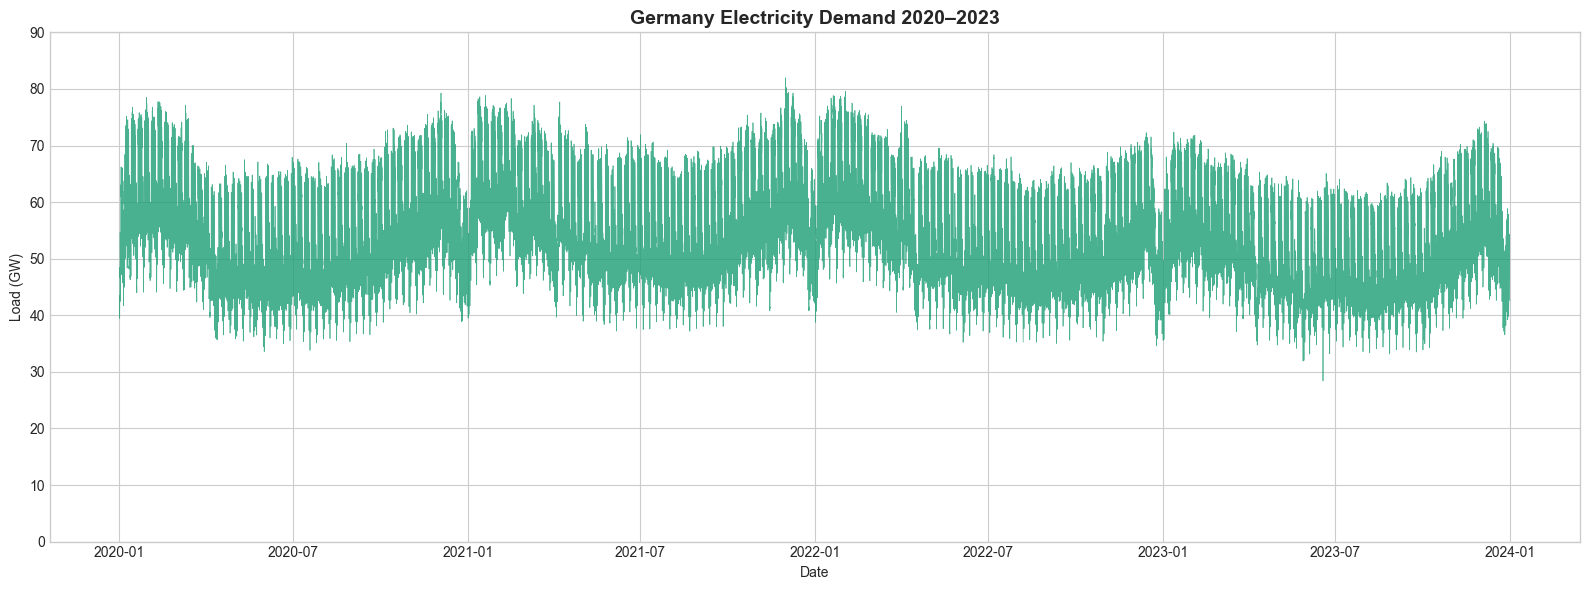

In [24]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df["Load_MW"] / 1000, 
        color="#1D9E75", 
        linewidth=0.5, 
        alpha=0.8)

ax.set_title("Germany Electricity Demand 2020–2023", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Load (GW)")
ax.set_ylim(0, 90)

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/01_load_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

#### Typical Week — Germany Electricity Demand (Jan 2023)

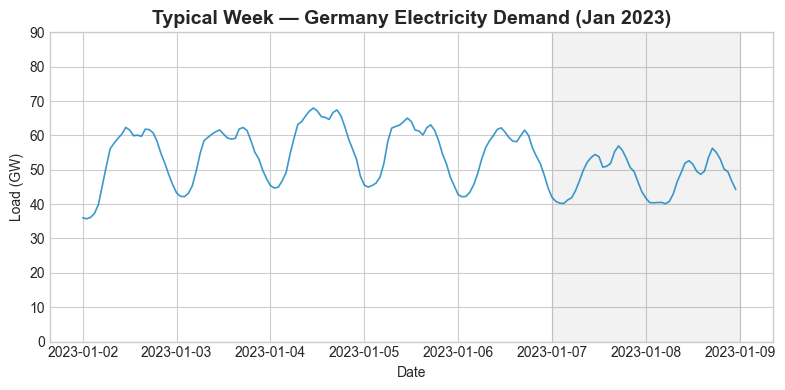

In [18]:
fig, ax = plt.subplots(figsize = (8,4))

ax.plot(df["Load_MW"].loc["2023-01-02":"2023-01-08"] / 1000, 
        color="#0B80BE", 
        linewidth=1.2, 
        alpha=0.8)

ax.axvspan("2023-01-07", "2023-01-09", 
            alpha=0.1, color="gray", label="Weekend")

ax.set_title("Typical Week — Germany Electricity Demand (Jan 2023)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Load (GW)")
ax.set_ylim(0, 90)

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/02_load_week.png", dpi=150, bbox_inches="tight")
plt.show()

### Average Hourly Load Profile — Germany

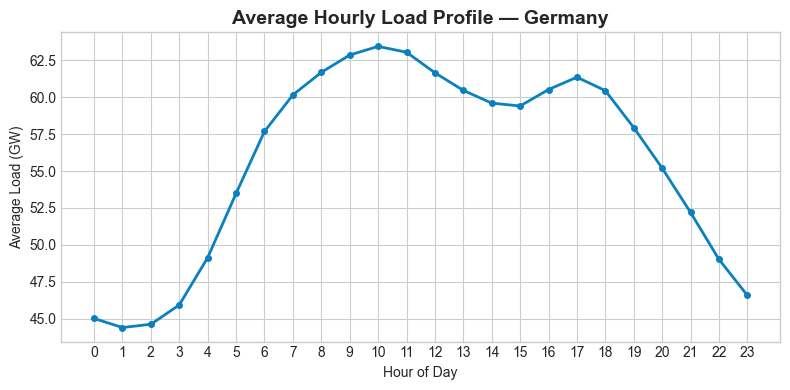

In [22]:
hourly_avg = df.groupby(df.index.hour)["Load_MW"].mean() / 1000

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly_avg,
        color="#0B80BE",
        linewidth=2,
        marker="o",
        markersize=4)

ax.set_title("Average Hourly Load Profile — Germany", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Load (GW)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/03_hourly_profile.png", 
            dpi=150, bbox_inches="tight")
plt.show()

### Electricity Demand vs Temperature — Germany 2020–2023

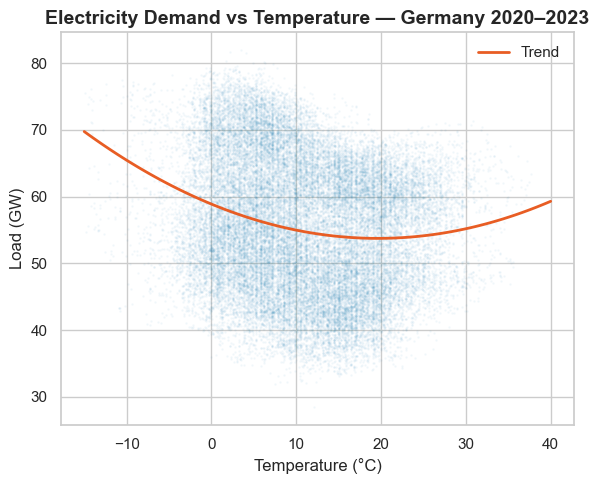

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(df["temperature_2m"],
           df["Load_MW"] / 1000,
           alpha=0.03,
           color="#0B80BE",
           s=1)

# Trend-Linie (Polynomgrad 2 = U-Form)
z = np.polyfit(df["temperature_2m"], df["Load_MW"] / 1000, 2)
p = np.poly1d(z)
x_line = np.linspace(-15, 40, 100)
ax.plot(x_line, p(x_line), color="#E85D24", linewidth=2, label="Trend")
ax.legend()

ax.set_title("Electricity Demand vs Temperature — Germany 2020–2023",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Load (GW)")

plt.tight_layout()
plt.savefig("/Users/saif/Desktop/ML_Load_Forecasting/figures/04_temp_vs_load.png",
            dpi=150, bbox_inches="tight")
plt.show()